# ***# Assignment 5: Exploratory Data Analysis on a Dataset (Cardiotocographic.csv)***

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

***1. Data Cleaning and Preparation***

In [10]:
df = pd.read_csv("/content/Cardiotocographic.csv")

In [11]:
print("--- Missing Values Before Imputation ---")
print(df.isnull().sum())

--- Missing Values Before Imputation ---
LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64


In [12]:
#missing numerical values with their median
df = df.fillna(df.median())
df["NSP"] = df["NSP"].astype(int)

In [13]:
# Step 4: Detect and treat outliers (IQR Method capping)
def cap_outliers(data, columns):
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data[col] = np.clip(data[col], lower_bound, upper_bound)
    return data


num_cols = [col for col in df.columns if col not in ["NSP", "Tendency"]]
df_clean = cap_outliers(df.copy(), num_cols)

print("\n--- Data Cleaning Complete ---")
print(df_clean.info())


--- Data Cleaning Complete ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   float64
 12  Tendency  2126 non-null   float64
 13  NSP       2126 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 232.7 KB
None


# ** 2. Statistical Summary**

In [14]:
summary_stats = []
for col in df_clean.columns:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    summary_stats.append(
        {
            "Variable": col,
            "Mean": df_clean[col].mean(),
            "Median": df_clean[col].median(),
            "Std Dev": df_clean[col].std(),
            "IQR": iqr,
        }
    )

summary_df = pd.DataFrame(summary_stats)
print("\n--- Statistical Summary ---")
print(summary_df)


--- Statistical Summary ---
    Variable        Mean      Median    Std Dev        IQR
0         LB  133.290331  133.000000   9.930268  14.000000
1         AC    0.003132    0.001634   0.003828   0.005606
2         FM    0.001568    0.000000   0.002485   0.002567
3         UC    0.004362    0.004484   0.003001   0.004685
4         DL    0.001770    0.000000   0.002668   0.003289
5         DS    0.000000    0.000000   0.000000   0.000000
6         DP    0.000000    0.000000   0.000000   0.000000
7       ASTV   46.981873   49.000000  17.612745  29.000000
8       MSTV    1.304644    1.200000   0.781091   1.000000
9       ALTV    6.691678    0.000000  10.378400  11.000000
10      MLTV    8.007471    7.400000   5.047078   6.200000
11     Width   70.287203   67.000000  39.571995  63.000000
12  Tendency    0.313246    0.000000   0.643186   1.000000
13       NSP    1.276576    1.000000   0.664875   0.000000


# ** 3. Data Visualization**

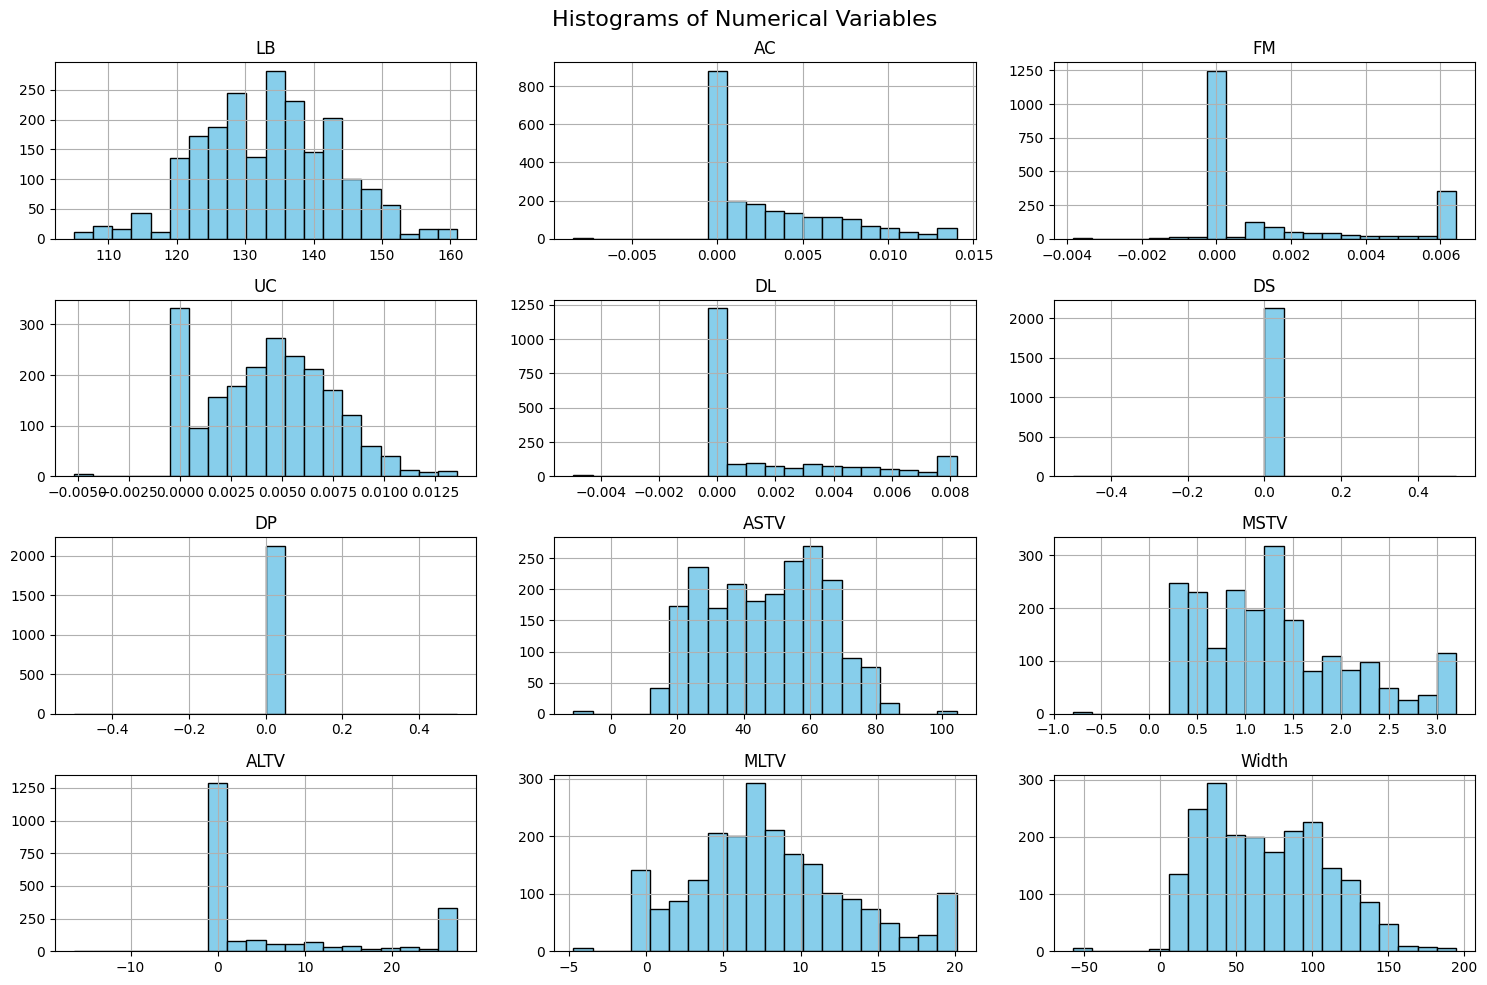

In [15]:
# Histograms for numerical variables
df_clean[num_cols].hist(bins=20, figsize=(15, 10), color="skyblue", edgecolor="black")
plt.suptitle("Histograms of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_897/10637257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NSP", y="ASTV", data=df_clean, palette="Set2")


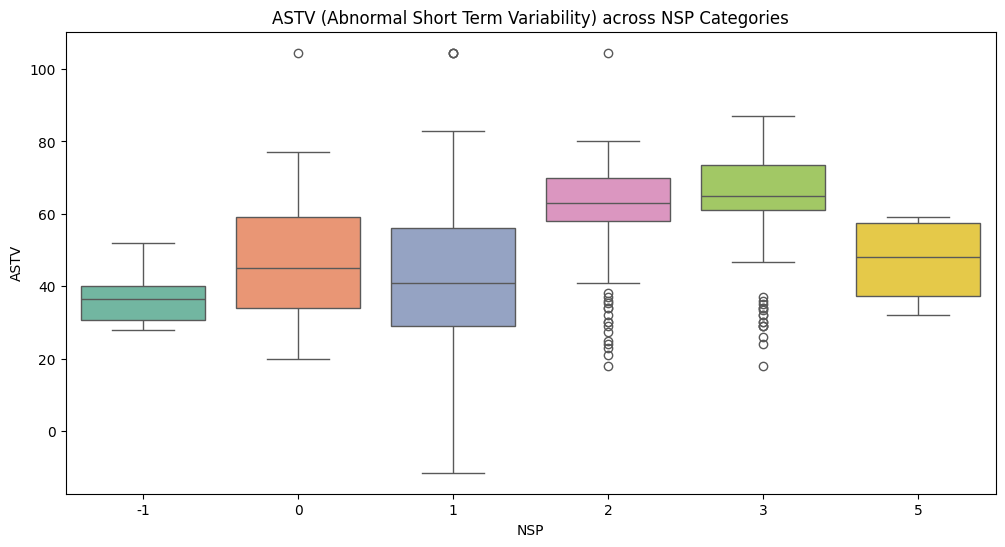

In [16]:
# Boxplots to check distributions across target class NSP
plt.figure(figsize=(12, 6))
sns.boxplot(x="NSP", y="ASTV", data=df_clean, palette="Set2")
plt.title("ASTV (Abnormal Short Term Variability) across NSP Categories")
plt.show()


/tmp/ipykernel_897/373379719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="NSP", data=df_clean, palette="viridis")


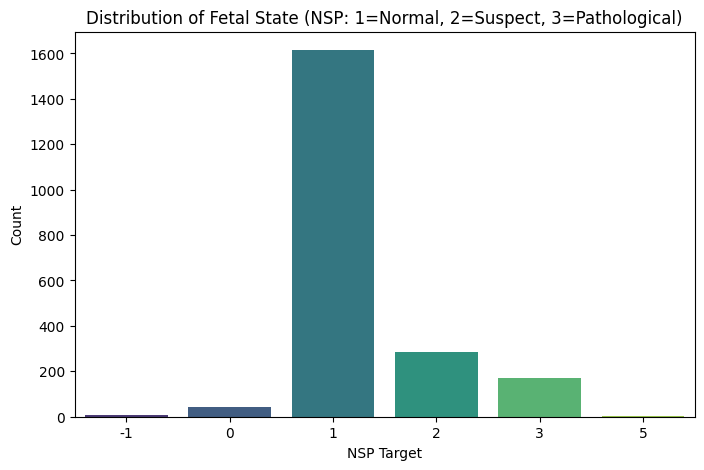

In [17]:
# Bar Chart for Categorical Target Variable (NSP)
plt.figure(figsize=(8, 5))
sns.countplot(x="NSP", data=df_clean, palette="viridis")
plt.title("Distribution of Fetal State (NSP: 1=Normal, 2=Suspect, 3=Pathological)")
plt.xlabel("NSP Target")
plt.ylabel("Count")
plt.show()

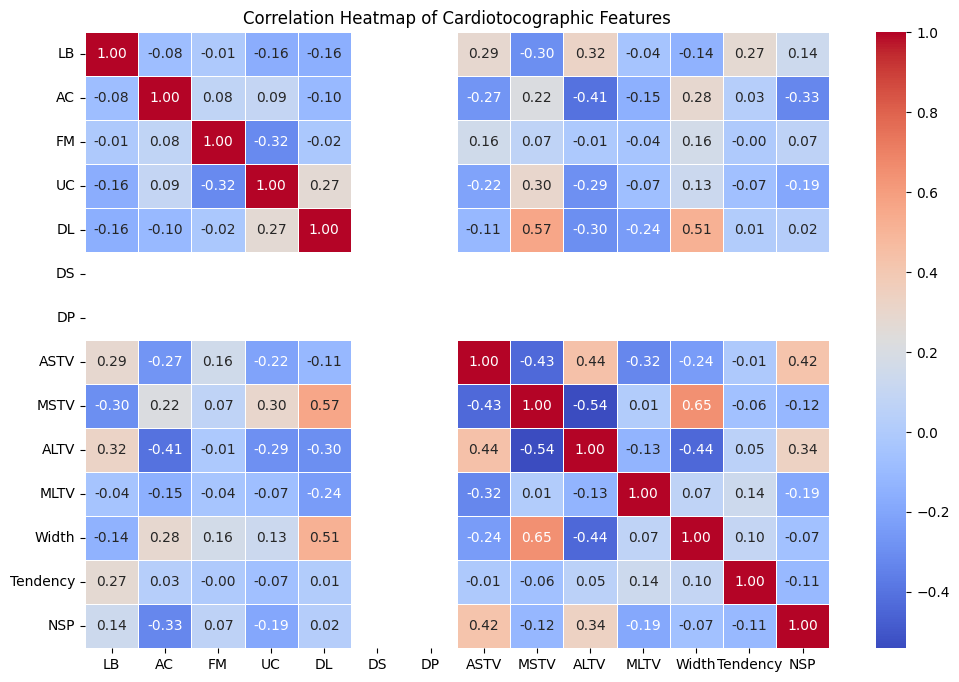

In [18]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Cardiotocographic Features")
plt.show()

/tmp/ipykernel_897/2352695067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="NSP", y="LB", data=df_clean, palette="muted")


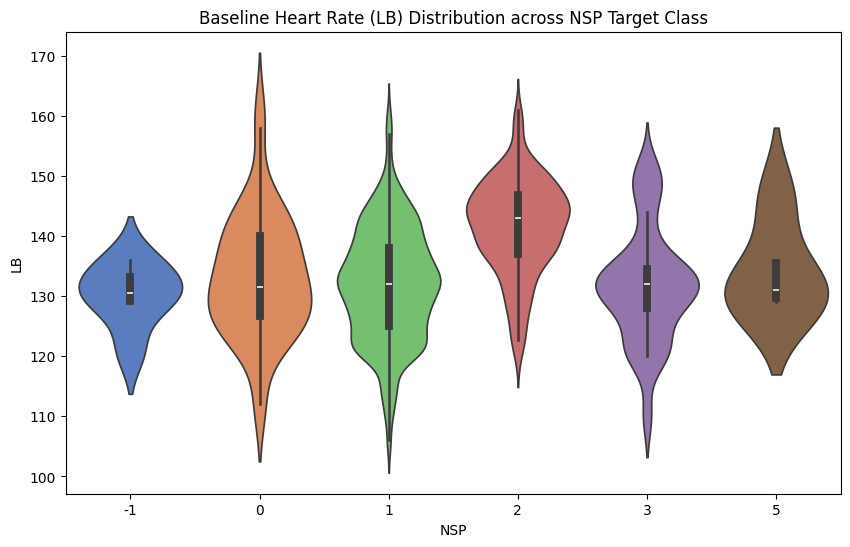

In [19]:
# Advanced Visualization: Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="NSP", y="LB", data=df_clean, palette="muted")
plt.title("Baseline Heart Rate (LB) Distribution across NSP Target Class")
plt.show()

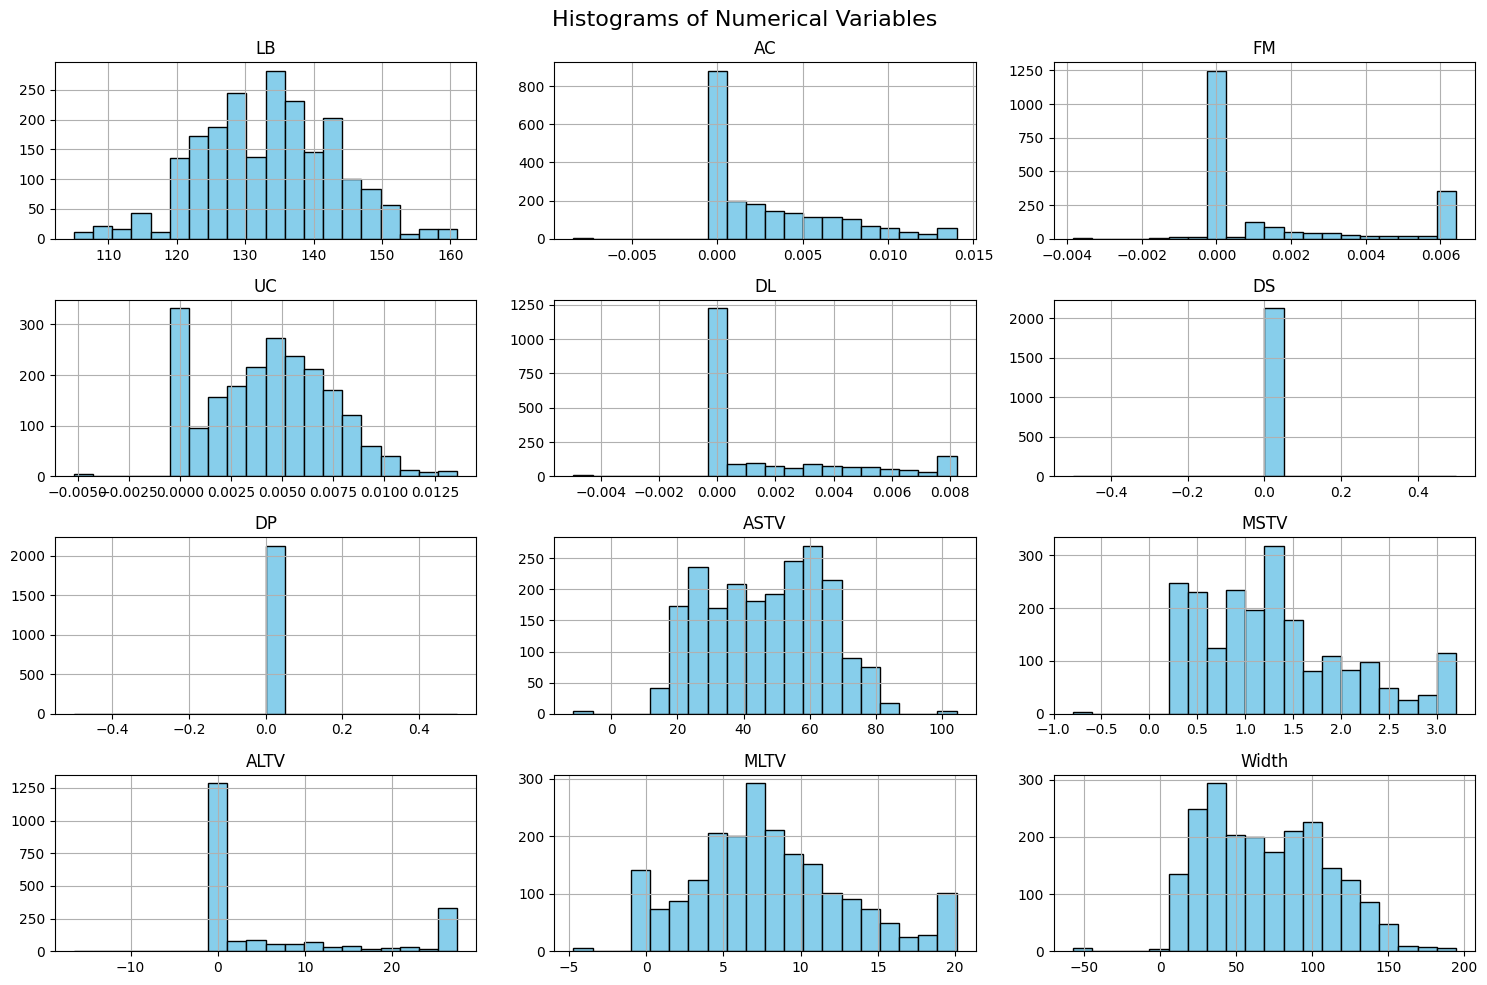

/tmp/ipykernel_897/3362494832.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NSP", y="ASTV", data=df_clean, palette="Set2")


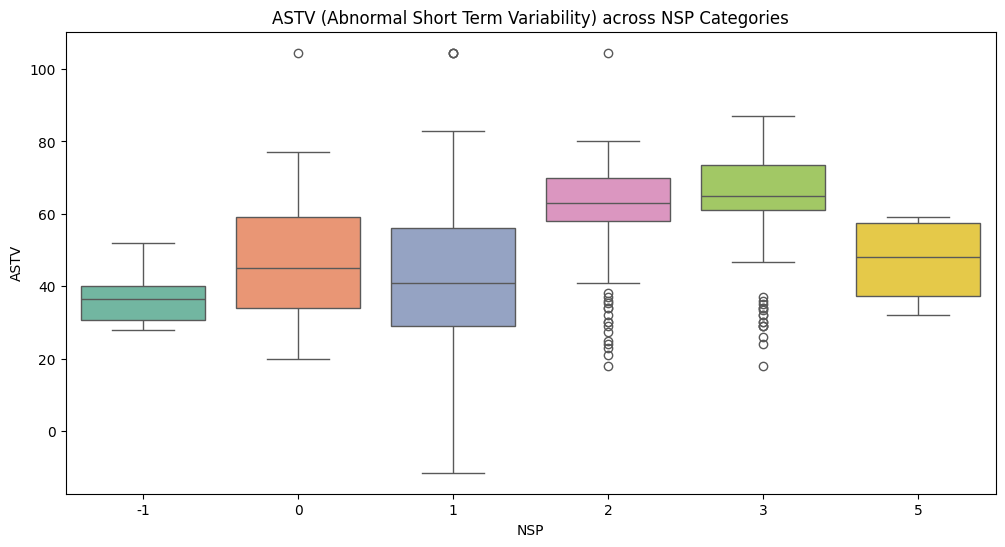

/tmp/ipykernel_897/3362494832.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="NSP", data=df_clean, palette="viridis")


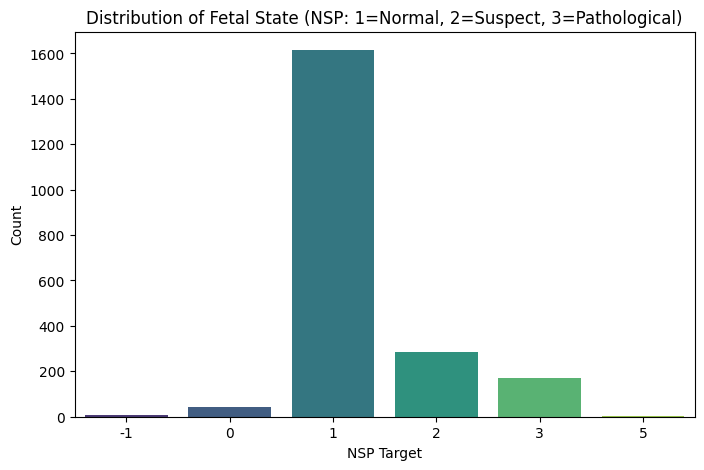

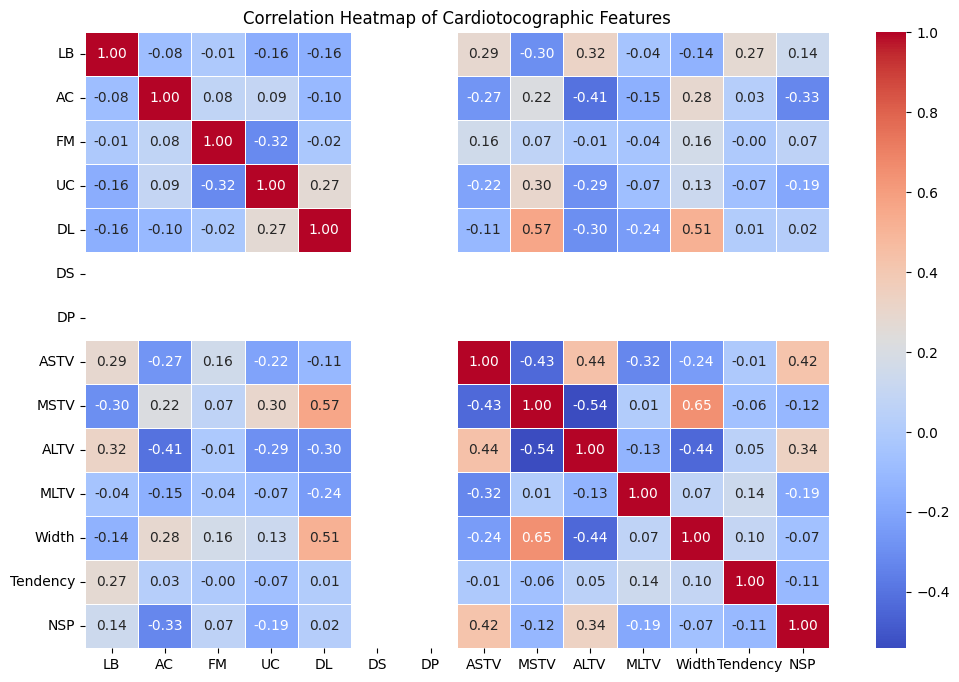

/tmp/ipykernel_897/3362494832.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="NSP", y="LB", data=df_clean, palette="muted")


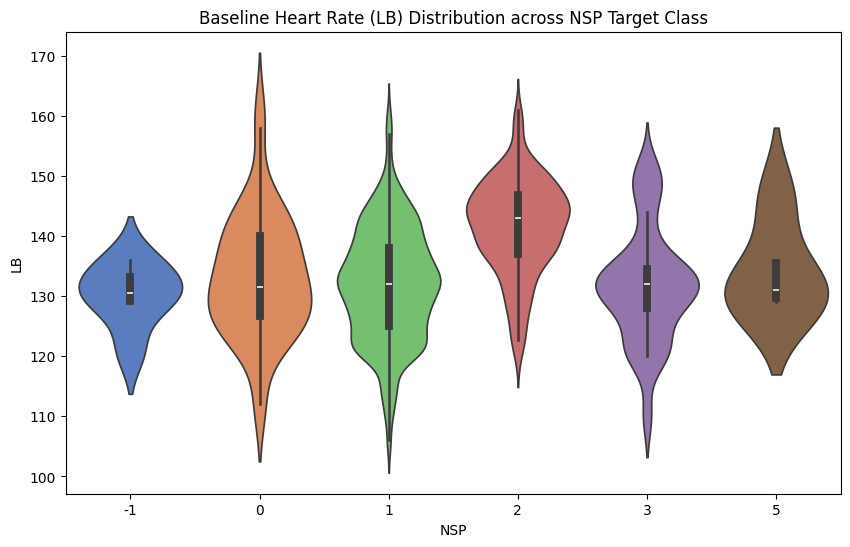

In [21]:
# Histograms for numerical variables
df_clean[num_cols].hist(bins=20, figsize=(15, 10), color="skyblue", edgecolor="black")
plt.suptitle("Histograms of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplots to check distributions across target class NSP
plt.figure(figsize=(12, 6))
sns.boxplot(x="NSP", y="ASTV", data=df_clean, palette="Set2")
plt.title("ASTV (Abnormal Short Term Variability) across NSP Categories")
plt.show()

# Bar Chart for Categorical Target Variable (NSP)
plt.figure(figsize=(8, 5))
sns.countplot(x="NSP", data=df_clean, palette="viridis")
plt.title("Distribution of Fetal State (NSP: 1=Normal, 2=Suspect, 3=Pathological)")
plt.xlabel("NSP Target")
plt.ylabel("Count")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Cardiotocographic Features")
plt.show()

# Advanced Visualization: Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="NSP", y="LB", data=df_clean, palette="muted")
plt.title("Baseline Heart Rate (LB) Distribution across NSP Target Class")
plt.show()